# 1. Stock Market ML Pipeline

## 1.1 Objective

This notebook builds the first end-to-end machine learning pipeline for the trading project.

The goal is not to build the best possible predictive model, but to create a clean and reusable workflow that:

- loads the data from local CSV files
- selects one company
- explores the data
- applies ETL and feature engineering
- trains and evaluates simple models
- keeps the pipeline ready for later integration into Streamlit

## 1.2 Project Scope

The assignment requires a machine learning model that:

- makes predictions daily
- predicts one trading day ahead
- is built in Python

We start with the simplest version of the problem: a binary classification model that predicts whether the next day's closing price will go up or down.

# 2. Imports

In [1]:
# Install packages if needed (run only once)
# %pip install simfin
# %pip install python-dotenv

# Standard library
import os
import warnings
from itertools import product
from pathlib import Path

# Third-party libraries
import joblib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import simfin as sf
from dotenv import load_dotenv

# Scikit-learn: preprocessing, models, pipeline, and evaluation
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    matthews_corrcoef
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Suppress future warnings for cleaner notebook output
warnings.filterwarnings("ignore", category=FutureWarning)

# 3. Load the Data

The data comes from SimFin which allows the Data to be downloaded using python, the idea is to so that once and turn those DFs into CSV files to use in the future

The required files are:

- Share Prices
- Companies
- Industry

### 3.1 Set Up SimFin (delete or use dotenv)

Set the API key and define the local data directory for SimFin downloads.


In [2]:
# Setting the SimFin API-key for downloading data.

load_dotenv("SIMFIN_API_KEY.env")

api_key = os.getenv("SIMFIN_API_KEY")

if not api_key:
    raise ValueError("SIMFIN_API_KEY is not set.")

sf.set_api_key(api_key)
sf.set_data_dir('~/simfin_data/')

### 3.2 Define Dataset Fetch Functions

Define separate functions for loading share prices, industries, and company information from SimFin.

In [3]:
def get_or_create_csv(path, fetch_func):
    path = Path(path)

    # Make sure the parent folder exists
    path.parent.mkdir(parents=True, exist_ok=True)

    try:
        return pd.read_csv(path)
    except FileNotFoundError:
        df = fetch_func()
        df.to_csv(path, index=True)
        return df

def fetch_share_prices():
    return sf.load_shareprices(variant="daily")

def fetch_industries():
    return sf.load_industries()

def fetch_companies():
    return sf.load_companies(market="us")

In [4]:
def ensure_index(df, index_cols):
    # If all requested index columns are already in the index, do nothing
    if isinstance(df.index, pd.MultiIndex):
        current_index_names = list(df.index.names)
    else:
        current_index_names = [df.index.name]

    if current_index_names == index_cols:
        return df

    # If the columns exist as normal columns, set them as index
    if all(col in df.columns for col in index_cols):
        return df.set_index(index_cols)

    # If some are already index and some are columns, reset and rebuild cleanly
    temp = df.reset_index()
    if all(col in temp.columns for col in index_cols):
        return temp.set_index(index_cols)

    raise KeyError(f"Could not set index {index_cols}. Available columns: {list(df.columns)}, index names: {current_index_names}")

### 3.3 Load or Create the Datasets & Add Indexes

Use the helper function to either load the existing CSV files or generate them from SimFin data.

In [5]:
# Using the functions to fetch data
share_prices = get_or_create_csv("CSVs/share_prices.csv", fetch_share_prices)
industry = get_or_create_csv("CSVs/industries.csv", fetch_industries)
companies = get_or_create_csv("CSVs/us-companies.csv", fetch_companies)

# Safe indexes
share_prices = ensure_index(share_prices, ['Ticker', 'Date'])
companies = ensure_index(companies, ['Ticker'])
industry = ensure_index(industry, ['IndustryId'])

### 3.4 Quick Verification
After loading the CSV files, we verify that the datasets were read correctly by checking:

In [6]:
print("Share Prices shape:", share_prices.shape)

print("Companies shape:", companies.shape)

print("Industry shape:", industry.shape)

Share Prices shape: (6206371, 9)
Companies shape: (6531, 10)
Industry shape: (74, 2)


In [7]:
print("Share Prices columns:")
print(share_prices.columns)

print("\nCompanies columns:")
print(companies.columns)

print("\nIndustry columns:")
print(industry.columns)

Share Prices columns:
Index(['SimFinId', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume',
       'Dividend', 'Shares Outstanding'],
      dtype='object')

Companies columns:
Index(['SimFinId', 'Company Name', 'IndustryId', 'ISIN',
       'End of financial year (month)', 'Number Employees', 'Business Summary',
       'Market', 'CIK', 'Main Currency'],
      dtype='object')

Industry columns:
Index(['Industry', 'Sector'], dtype='object')


In [8]:
print("Share Prices index names:", share_prices.index.names)
print("Companies index name:", companies.index.name)
print("Industry index name:", industry.index.name)

Share Prices index names: ['Ticker', 'Date']
Companies index name: Ticker
Industry index name: IndustryId


### 3.5 Quick Exploration


In [9]:
display(share_prices.head())
display(companies.head())

SimFinId   Open   High    Low  Close  Adj. Close   Volume  \
Ticker Date                                                                    
A      2020-04-09     45846  76.43  78.72  76.23  78.33       75.31  2399863   
       2020-04-13     45846  77.44  77.99  75.02  76.21       73.27  1533000   
       2020-04-14     45846  77.30  79.20  77.24  78.83       75.79  2650262   
       2020-04-15     45846  77.44  78.39  77.00  77.05       74.07  2721130   
       2020-04-16     45846  78.06  78.92  76.47  78.75       75.71  1963426   

                   Dividend  Shares Outstanding  
Ticker Date                                      
A      2020-04-09       NaN         309651359.0  
       2020-04-13       NaN         309651359.0  
       2020-04-14       NaN         309651359.0  
       2020-04-15       NaN         309651359.0  
       2020-04-16       NaN         309651359.0

,SimFinId,Company Name,IndustryId,ISIN,End of financial year (month),Number Employees,Business Summary,Market,CIK,Main Currency
Ticker,,,,,,,,,,
A,45846,AGILENT TECHNOLOGIES INC,106001.0,US00846U1016,10.0,16400.0,Agilent Technologies Inc is engaged in life sc...,us,1090872.0,USD
A21,1333027,Li Auto Inc.,NaN,NaN,12.0,NaN,NaN,us,1791706.0,USD
AA,367153,Alcoa Corp,110004.0,US0138721065,12.0,12900.0,Alcoa Corp is an integrated aluminum company. ...,us,1675149.0,USD
AAC,7962652,Ares Acquisition Corporation,104002.0,US0003071083,12.0,NaN,Ares Acquisition Corporation does not have sig...,us,1829432.0,USD
AACB,18959140,Artius II Acquisition Inc. Class A Ordinary Sh...,104002.0,KYG0509J1076,12.0,NaN,Artius II Acquisition Inc. is a blank check co...,us,2034334.0,USD


#### 3.5.1 Industry DF
Looking at industry data to have an idea of what SimFin has available, however it is not used for this project

In [10]:
display(industry.head())

,Industry,Sector
IndustryId,,
100001,Industrial Products,Industrials
100002,Business Services,Industrials
100003,Engineering & Construction,Industrials
100004,Waste Management,Industrials
100005,Industrial Distribution,Industrials


### 3.6 Check Available Tickers

We inspect the distinct ticker symbols available in the `share_prices` dataset to confirm which companies can be selected for the pipeline.

In [11]:
tickers = share_prices.index.get_level_values('Ticker').unique()
print("Number of tickers:", len(tickers))
print("First 20 tickers:")
print(tickers[:20])

Number of tickers: 5859
First 20 tickers:
Index(['A', 'AA', 'AAC', 'AACG', 'AACI', 'AACT', 'AAGH', 'AAIC', 'AAL', 'AAM',
       'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAT', 'AATP',
       'AAWH'],
      dtype='object', name='Ticker')


# 4. Define Reusable Functions

Because the pipeline must later work for multiple companies, we define reusable functions for:

- selecting one company from the full dataset
- exploring raw company data
- building the ETL dataset
- exploring the ETL output
- splitting train and test sets in time order
- training and evaluating models

### 4.1 Function: Get One Company from Share Prices

This function receives:

- the full `share_prices` DataFrame
- a ticker symbol

and returns the raw time-series DataFrame for that company.

In [12]:
def get_company_df(share_prices, ticker):
    available_tickers = share_prices.index.get_level_values("Ticker").unique()

    if ticker not in available_tickers:
        raise ValueError(
            f"Ticker '{ticker}' not found in share_prices dataset."
        )

    return share_prices.loc[ticker]

## 4.2 Function: Explore Raw Company Data

This function is used before ETL.

It helps us inspect the raw data for a single company by showing:

- shape
- columns
- date range
- missing values
- summary statistics
- price charts
- volume chart

In [13]:
def explore_raw_company_df(df, company_name="Company"):

    print(f"=== Raw Data Exploration: {company_name} ===")
    print("\nShape:", df.shape)
    print("\nColumns:")
    print(df.columns.tolist())

    print("\nDate range:")
    print(df.index.min(), "to", df.index.max())

    print("\nMissing values:")
    print(df.isna().sum())

    display(df.head())
    display(df.tail())

    # Summary stats
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    print("\nSummary statistics:")
    display(df[numeric_cols].describe())

    def format_date_axis(ax):
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    
    
    # Closing price over time
    if 'Close' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Close'])
        ax.set_title(f'{company_name} - Closing Price Over Time')
        ax.set_xlabel('Date')
        ax.set_ylabel('Close')
        ax.grid(True)
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()
        print("*Note: The Date will be wrong since in the raw data, Date column is not in date format so it won't show the correct date, just a generic date from the 70s\nThat will be fixed after the ETL process")

    # Volume over time
    if 'Volume' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Volume'])
        ax.set_title(f'{company_name} - Volume Over Time')
        ax.set_xlabel('Date')
        ax.set_ylabel('Volume')
        ax.grid(True)
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()
        print("*Note: The Date will be wrong since in the raw data, Date column is not in date format so it won't show the correct date, just a generic date from the 70s\nThat will be fixed after the ETL process")

    # Close vs Adj. Close if available
    if 'Close' in df.columns and 'Adj. Close' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Close'], label='Close')
        ax.plot(df.index, df['Adj. Close'], label='Adj. Close')
        ax.set_title(f'{company_name} - Close vs Adjusted Close')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        ax.grid(True)
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()
        print("*Note: The Date will be wrong since in the raw data, Date column is not in date format so it won't show the correct date, just a generic date from the 70s\nThat will be fixed after the ETL process")


## 4.3 Function: Build the ETL Dataset

This is the main ETL function.

It should:

- receive one company DataFrame
- sort the data by date
- keep only the selected columns: `Open`, `Close`, and `Volume`
- create the engineered features:
  - `Daily_Change_Pct`: percentage change from open to close during the same day
  - `MA_5`: 5-day moving average of the closing price
  - `MA_10`: 10-day moving average of the closing price
- create the one-day-ahead target:
  - `Target = 1` if tomorrow’s closing price is higher than today’s closing price
  - `Target = 0` otherwise
- remove rows made invalid by rolling windows or missing future values
- return a clean ML-ready DataFrame with these columns:
  - `Open`
  - `Close`
  - `Daily_Change_Pct`
  - `MA_5`
  - `MA_10`
  - `Volume`
  - `Target`

In [14]:
def build_etl_dataset(company_df, ticker_name="Ticker"):
    df = company_df.copy()

    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    df = df[['Open', 'Close', 'Volume']].copy()

    df['Daily_Change_Pct'] = (df['Close'] - df['Open']) / df['Open']
    df['MA_5'] = df['Close'].rolling(window=5).mean()
    df['MA_10'] = df['Close'].rolling(window=10).mean()

    df['Close_tomorrow'] = df['Close'].shift(-1)
    df['Target'] = (df['Close_tomorrow'] > df['Close']).astype(int)

    rows_before = len(df)

    df = df.drop(columns=['Close_tomorrow'])
    df = df.dropna()

    rows_after = len(df)
    rows_dropped = rows_before - rows_after

    print(f"{ticker_name}: ETL complete: {rows_before} rows -> {rows_after} rows ({rows_dropped} dropped due to rolling features and target shift)")
    
    return df[['Open', 'Close', 'Daily_Change_Pct', 'MA_5', 'MA_10', 'Volume', 'Target']]

## 4.4 Function: Explore ETL Dataset

This function is used after ETL.

It helps verify that:

- the new features were created correctly
- missing values were removed
- the target distribution is reasonable
- the data is ready for model training

In [15]:
def explore_etl_df(df, company_name="Company"):
    print(f"=== ETL Data Exploration: {company_name} ===")
    print("\nShape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nDate range:")
    print(df.index.min(), "to", df.index.max())

    print("\nMissing values:")
    print(df.isna().sum())

    display(df.head())
    display(df.tail())

    # Summary statistics
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    print("\nSummary statistics:")
    display(df[numeric_cols].describe())

    # Target distribution
    if 'Target' in df.columns:
        print("\nTarget distribution:")
        print(df['Target'].value_counts())

        print("\nTarget distribution (proportion):")
        print(df['Target'].value_counts(normalize=True))

    # helper for date formatting
    def format_date_axis(ax):
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    # Close over time
    if 'Close' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Close'], label='Close')
        ax.set_title(f'{company_name} - Close Price')
        ax.set_xlabel('Date')
        ax.set_ylabel('Close')
        ax.grid(True)
        ax.legend()
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()

    # Daily_Change_Pct over time
    if 'Daily_Change_Pct' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Daily_Change_Pct'])
        ax.set_title(f'{company_name} - Daily Change %')
        ax.set_xlabel('Date')
        ax.set_ylabel('Daily_Change_Pct')
        ax.grid(True)
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.hist(df['Daily_Change_Pct'].dropna(), bins=50)
        plt.title(f'{company_name} - Daily Change % Distribution')
        plt.xlabel('Daily_Change_Pct')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.show()

    # Volume over time
    if 'Volume' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Volume'])
        ax.set_title(f'{company_name} - Volume')
        ax.set_xlabel('Date')
        ax.set_ylabel('Volume')
        ax.grid(True)
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()

    # Moving averages
    if 'Close' in df.columns and 'MA_5' in df.columns and 'MA_10' in df.columns:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(df.index, df['Close'], label='Close')
        ax.plot(df.index, df['MA_5'], label='MA_5')
        ax.plot(df.index, df['MA_10'], label='MA_10')
        ax.set_title(f'{company_name} - Close and Moving Averages')
        ax.set_xlabel('Date')
        ax.set_ylabel('Price')
        ax.legend()
        ax.grid(True)
        format_date_axis(ax)
        plt.tight_layout()
        plt.show()

    # Correlation matrix
    corr = df.select_dtypes(include='number').corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr, interpolation='none', aspect='auto')
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha='right')
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title(f'{company_name} - Correlation Matrix')
    plt.tight_layout()
    plt.show()

## 4.5 Function: Time-Based Split

Because this is time-ordered stock market data, the train/test split must preserve chronological order.

This helper function separates:

- `X` and `y`
- training data
- testing data

using a time-based split without shuffling.

Standard k-fold cross-validation is not appropriate for time-series data because it can mix past and future observations across folds. To preserve temporal order and better reflect a real prediction setting, this project uses chronological train/test splits instead.

In [16]:
def time_split(df_etl, target_col='Target', drop_cols=None, split_ratio=0.8):
    if drop_cols is None:
        drop_cols = []

    df_etl = df_etl.sort_index()

    X = df_etl.drop(columns=[target_col] + drop_cols, errors='ignore')
    y = df_etl[target_col]

    split_idx = int(len(df_etl) * split_ratio)

    X_train = X.iloc[:split_idx]
    X_test = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test = y.iloc[split_idx:]

    return X_train, X_test, y_train, y_test

## 4.6 Function: Model Evaluation Helper

This function standardizes evaluation across all models.

It should:

- compute train and test accuracy
- print the classification report
- print the confusion matrix
- build a results DataFrame with:
  - actual target
  - predicted target
  - predicted probability
  - correct/incorrect indicator
  - human-readable labels
- display a styled preview table
- plot the confusion matrix

In [17]:
def highlight_correct(row):
    bg = '#228b22' if row['Correct'] else '#ff0000'
    return [f'background-color: {bg}; color: black'] * len(row)


def evaluate_model_output(model_name, model, X_train, X_test, y_train, y_test):
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        test_pred_prob = model.predict_proba(X_test)[:, 1]
        roc_auc = roc_auc_score(y_test, test_pred_prob)
    else:
        test_pred_prob = np.full(len(y_test), np.nan)
        roc_auc = np.nan

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    precision = precision_score(y_test, test_pred, zero_division=0)
    recall = recall_score(y_test, test_pred, zero_division=0)
    f1 = f1_score(y_test, test_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, test_pred)
    mcc = matthews_corrcoef(y_test, test_pred)

    print(f"{model_name} - Train Accuracy: {train_acc:.4f}")
    print(f"{model_name} - Test Accuracy: {test_acc:.4f}")
    print(f"{model_name} - Precision: {precision:.4f}")
    print(f"{model_name} - Recall: {recall:.4f}")
    print(f"{model_name} - F1 Score: {f1:.4f}")
    print(f"{model_name} - Balanced Accuracy: {bal_acc:.4f}")
    print(f"{model_name} - MCC: {mcc:.4f}")
    print(f"{model_name} - ROC-AUC: {roc_auc:.4f}")

    print(f"\n{model_name} - Classification Report:")
    print(classification_report(y_test, test_pred))

    cm = confusion_matrix(y_test, test_pred)
    print(f"{model_name} - Confusion Matrix:")
    print(cm)

    results_df = pd.DataFrame(index=y_test.index.copy())
    results_df['Actual'] = y_test.values
    results_df['Predicted'] = test_pred
    results_df['Prob_Up'] = test_pred_prob
    results_df['Correct'] = results_df['Actual'] == results_df['Predicted']
    results_df['Actual_Label'] = results_df['Actual'].map({1: 'Up', 0: 'Down'})
    results_df['Predicted_Label'] = results_df['Predicted'].map({1: 'Up', 0: 'Down'})

    styled = (
        results_df.head(20)
        .style
        .apply(highlight_correct, axis=1)
        .format({'Prob_Up': '{:.3f}'}, na_rep='-')
        .set_properties(**{'color': 'black'})
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Down', 'Up'])
    disp.plot(ax=ax, values_format='d', colorbar=False)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

    return {
        "model": model,
        "train_accuracy": train_acc,
        "test_accuracy": test_acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "balanced_accuracy": bal_acc,
        "mcc": mcc,
        "roc_auc": roc_auc,
        "results_df": results_df,
        "styled_results": styled,
        "confusion_matrix": cm,
        "train_pred": train_pred,
        "test_pred": test_pred,
        "test_pred_prob": test_pred_prob
    }

## 4.7 Function: Logistic Regression Model

This function trains and evaluates the Logistic Regression model.

Because Logistic Regression is sensitive to feature scale, this function should handle scaling internally.

In [18]:
def run_logistic_regression(df_etl):
    X_train, X_test, y_train, y_test = time_split(
        df_etl.sort_index(),
        target_col='Target'
    )

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=1000, random_state=42))
    ])

    model.fit(X_train, y_train)

    output = evaluate_model_output(
        model_name="Logistic Regression",
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

    output["X_train"] = X_train
    output["X_test"] = X_test
    output["y_train"] = y_train
    output["y_test"] = y_test

    return output

## 4.8 Tuning and Training Gradient Boosting Classifier

This function trains and evaluates the Gradient Boosted Trees model.

Unlike Logistic Regression, this tree-based model does not require scaling.

### 4.8.1 Function: Adjusting Hyper Parameters
After adjusting the Gradient Boosted Trees hyperparameters, the model achieved better test performance than Logistic Regression across all key evaluation metrics, including test accuracy, F1 score, balanced accuracy, and ROC-AUC. It also showed a smaller overfitting gap, indicating better generalization. Based on this comparison, Gradient Boosted Trees was selected as the final model to apply across all tickers.

In [19]:
def find_best_gb_params(df_etl):
    X_train, X_test, y_train, y_test = time_split(
        df_etl.sort_index(),
        target_col='Target'
    )

    param_grid = {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.02, 0.05],
        "max_depth": [1, 2],
        "subsample": [0.6, 0.7, 0.8],
        "min_samples_split": [10, 20],
        "min_samples_leaf": [5, 10]
    }

    keys = list(param_grid.keys())
    combinations = list(product(*param_grid.values()))

    best_params = None
    best_score = -1
    results = []

    for values in combinations:
        params = dict(zip(keys, values))

        model = GradientBoostingClassifier(
            random_state=42,
            **params
        )
        model.fit(X_train, y_train)

        test_pred = model.predict(X_test)
        test_prob = model.predict_proba(X_test)[:, 1]

        bal_acc = balanced_accuracy_score(y_test, test_pred)
        f1 = f1_score(y_test, test_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, test_prob)

        results.append({
            **params,
            "Balanced Accuracy": bal_acc,
            "F1 Score": f1,
            "ROC-AUC": roc_auc
        })

        if bal_acc > best_score:
            best_score = bal_acc
            best_params = params

    results_df = pd.DataFrame(results).sort_values(
        "Balanced Accuracy", ascending=False
    )

    return best_params, results_df

### 4.8.2 Function: Gradient Boosting Classifier Training Function

In [20]:
def run_gradient_boosting(df_etl, params=None):
    X_train, X_test, y_train, y_test = time_split(
        df_etl.sort_index(),
        target_col='Target'
    )

    default_params = {
        "n_estimators": 100,
        "learning_rate": 0.05,
        "max_depth": 2,
        "subsample": 0.8,
        "random_state": 42
    }

    if params is not None:
        default_params.update(params)

    model = GradientBoostingClassifier(**default_params)
    model.fit(X_train, y_train)

    output = evaluate_model_output(
        model_name="Gradient Boosted Trees",
        model=model,
        X_train=X_train,
        X_test=X_test,
        y_train=y_train,
        y_test=y_test
    )

    output["X_train"] = X_train
    output["X_test"] = X_test
    output["y_train"] = y_train
    output["y_test"] = y_test
    output["best_params"] = default_params

    return output

# 5. Testing with One Company (Apple)

The project instructions recommend building the full pipeline for one company first.

In this notebook, we select one ticker, extract its raw time-series DataFrame, and inspect its metadata before continuing.

We extract it's data with the funcion "get_company_df"

In [21]:
# Select company
ticker = "AAPL"

df_raw_AAPL = get_company_df(share_prices, ticker)

Info about the company

In [22]:
companies.loc[ticker]

SimFinId                                                                    111052
Company Name                                                             APPLE INC
IndustryId                                                                101001.0
ISIN                                                                  US0378331005
End of financial year (month)                                                  9.0
Number Employees                                                          147000.0
Business Summary                 Apple Inc is an American multinational technol...
Market                                                                          us
CIK                                                                       320193.0
Main Currency                                                                  USD
Name: AAPL, dtype: object

## 5.1 Explore the Raw Company Data

Before applying ETL, we inspect the raw company data to understand:

- the date range
- missing values
- price evolution
- volume behavior

This helps confirm that the input data is usable and consistent.

=== Raw Data Exploration: AAPL ===

Shape: (1238, 9)

Columns:
['SimFinId', 'Open', 'High', 'Low', 'Close', 'Adj. Close', 'Volume', 'Dividend', 'Shares Outstanding']

Date range:
2020-04-09 to 2025-03-13

Missing values:
SimFinId                 0
Open                     0
High                     0
Low                      0
Close                    0
Adj. Close               0
Volume                   0
Dividend              1218
Shares Outstanding       0
dtype: int64


,SimFinId,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
Date,,,,,,,,,
2020-04-09,111052,67.17,67.52,66.17,67.00,64.76,162116492,NaN,1.729595e+10
2020-04-13,111052,67.08,68.42,66.46,68.31,66.03,131022924,NaN,1.729595e+10
2020-04-14,111052,70.00,72.06,69.51,71.76,69.37,194994688,NaN,1.729595e+10
2020-04-15,111052,70.60,71.58,70.16,71.11,68.73,131154564,NaN,1.729595e+10
2020-04-16,111052,71.84,72.05,70.59,71.67,69.28,157125160,NaN,1.729595e+10


,SimFinId,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
Date,,,,,,,,,
2025-03-07,111052,235.10,241.37,234.76,239.07,238.05,46273565,NaN,1.502207e+10
2025-03-10,111052,235.54,236.16,224.22,227.48,226.51,71451281,NaN,1.502207e+10
2025-03-11,111052,223.81,225.84,217.45,220.84,219.90,76137410,NaN,1.502207e+10
2025-03-12,111052,220.14,221.75,214.91,216.98,216.05,62547467,NaN,1.502207e+10
2025-03-13,111052,215.95,216.84,208.42,209.68,208.78,61368330,NaN,1.502207e+10



Summary statistics:


,SimFinId,Open,High,Low,Close,Adj. Close,Volume,Dividend,Shares Outstanding
count,1238.0,1238.000000,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03,20.000000,1.238000e+03
mean,111052.0,161.584111,163.349887,159.921139,161.722997,159.195073,8.335872e+07,0.228000,1.615238e+10
std,0.0,39.738334,39.974904,39.519749,39.783049,40.293759,4.312142e+07,0.017652,6.756276e+08
min,111052.0,67.080000,67.520000,66.170000,67.000000,64.760000,2.323470e+07,0.200000,1.502207e+10
25%,111052.0,134.807500,136.070000,133.342500,134.730000,131.327500,5.363435e+07,0.220000,1.569761e+10
50%,111052.0,159.370000,161.370000,157.080000,159.250000,156.215000,7.268622e+07,0.230000,1.616294e+10
75%,111052.0,183.875000,185.345000,182.205000,184.080000,182.157500,9.895951e+07,0.240000,1.668763e+10
max,111052.0,258.190000,260.100000,257.630000,259.020000,257.630000,3.742955e+08,0.250000,1.733734e+10


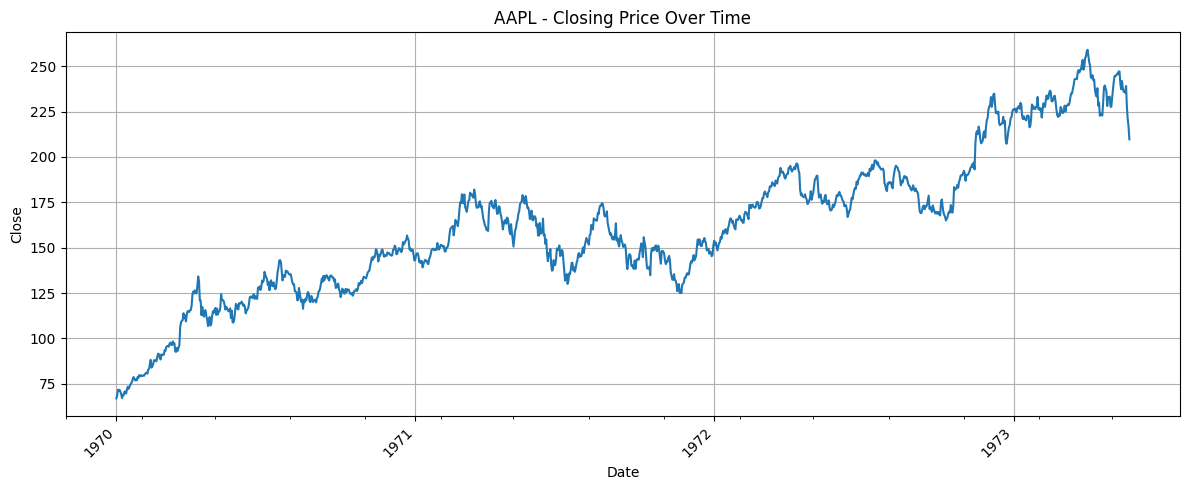

*Note: The Date will be wrong since in the raw data, Date column is not in date format so it won't show the correct date, just a generic date from the 70s
That will be fixed after the ETL process


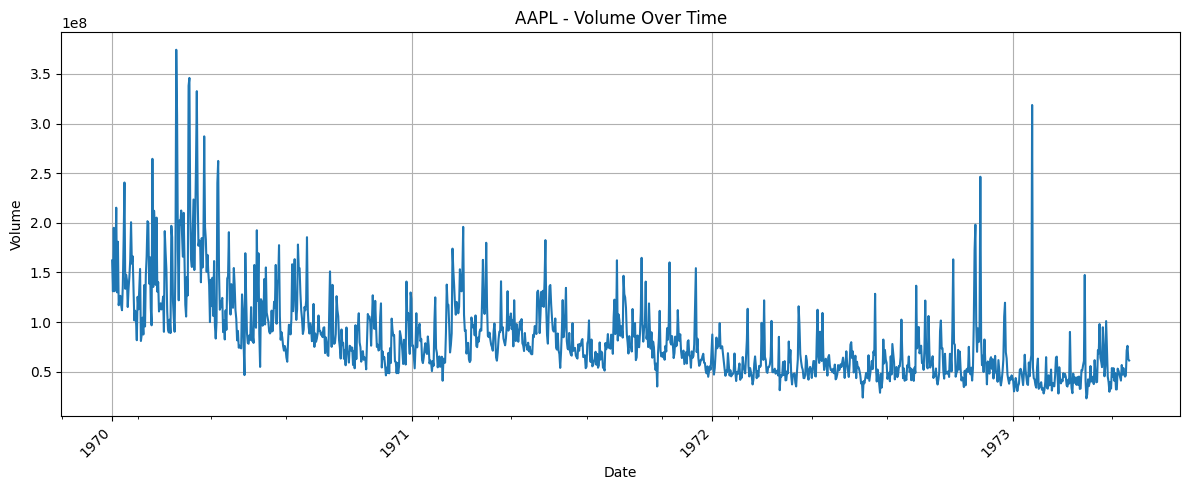

*Note: The Date will be wrong since in the raw data, Date column is not in date format so it won't show the correct date, just a generic date from the 70s
That will be fixed after the ETL process


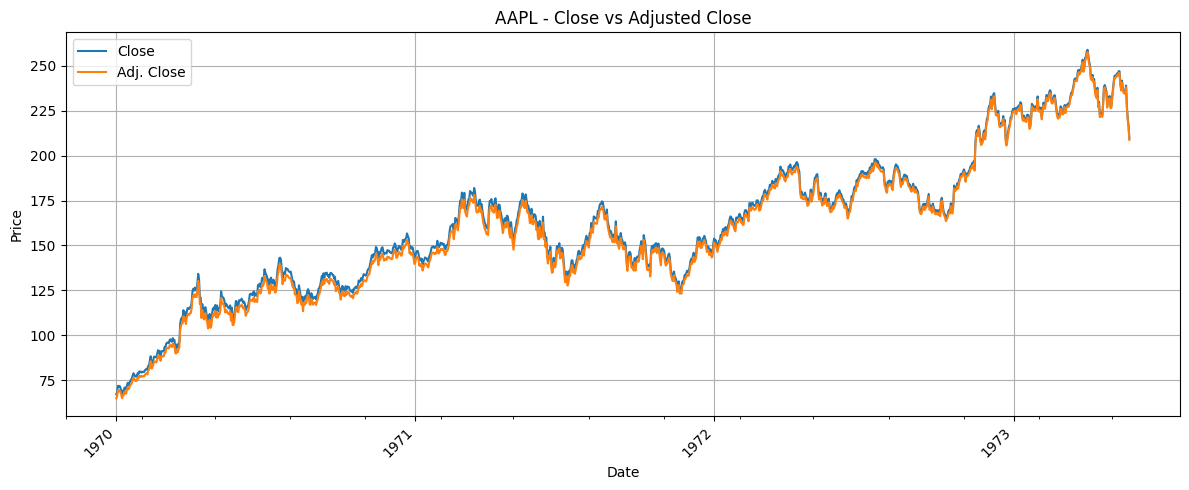

*Note: The Date will be wrong since in the raw data, Date column is not in date format so it won't show the correct date, just a generic date from the 70s
That will be fixed after the ETL process


In [23]:
explore_raw_company_df(df_raw_AAPL, company_name=ticker)

# 6. Build the ETL Dataset

The ETL step transforms the raw stock time series into an ML-ready dataset.

The ETL function should:

- keep the selected useful columns
- create engineered features
- create the one-day-ahead target variable
- remove invalid rows

The target is predictive: for each day `t`, it indicates whether the closing price on day `t+1` is higher than the closing price on day `t`.

In [24]:
df_AAPL = build_etl_dataset(df_raw_AAPL, ticker_name=ticker)
df_AAPL.head()

AAPL: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,68.97,68.76,-0.003045,68.962,69.466,124814328,1
2020-04-24,69.30,70.74,0.020779,68.970,69.840,126508732,1
2020-04-27,70.45,70.79,0.004826,69.282,70.088,117087572,0
2020-04-28,71.27,69.64,-0.022871,69.792,69.876,112004748,1
2020-04-29,71.18,71.93,0.010537,70.372,69.958,137280816,1


In [25]:
print(df_AAPL.shape)
print(df_AAPL.columns.tolist())

(1229, 7)
['Open', 'Close', 'Daily_Change_Pct', 'MA_5', 'MA_10', 'Volume', 'Target']


## 6.1 Explore the ETL Output

After ETL, we inspect the enriched dataset to confirm that:

- the new features were created correctly
- missing values were removed
- the target distribution is reasonable
- the dataset is ready for model training

=== ETL Data Exploration: AAPL ===

Shape: (1229, 7)

Columns:
['Open', 'Close', 'Daily_Change_Pct', 'MA_5', 'MA_10', 'Volume', 'Target']

Date range:
2020-04-23 00:00:00 to 2025-03-13 00:00:00

Missing values:
Open                0
Close               0
Daily_Change_Pct    0
MA_5                0
MA_10               0
Volume              0
Target              0
dtype: int64


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,68.97,68.76,-0.003045,68.962,69.466,124814328,1
2020-04-24,69.30,70.74,0.020779,68.970,69.840,126508732,1
2020-04-27,70.45,70.79,0.004826,69.282,70.088,117087572,0
2020-04-28,71.27,69.64,-0.022871,69.792,69.876,112004748,1
2020-04-29,71.18,71.93,0.010537,70.372,69.958,137280816,1


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2025-03-07,235.10,239.07,0.016886,236.820,239.774,46273565,0
2025-03-10,235.54,227.48,-0.034219,234.710,237.812,71451281,0
2025-03-11,223.81,220.84,-0.013270,231.692,235.192,76137410,0
2025-03-12,220.14,216.98,-0.014355,227.940,232.854,62547467,0
2025-03-13,215.95,209.68,-0.029034,222.810,230.092,61368330,0



Summary statistics:


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
count,1229.000000,1229.000000,1229.000000,1229.000000,1229.000000,1.229000e+03,1229.000000
mean,162.258999,162.398023,0.000970,162.158434,161.831789,8.281397e+07,0.532140
std,39.089468,39.134875,0.014830,39.176902,39.191781,4.271792e+07,0.499169
min,68.970000,68.760000,-0.057079,68.962000,69.466000,2.323470e+07,0.000000
25%,135.110000,135.130000,-0.007074,134.562000,135.180000,5.352237e+07,0.000000
50%,159.750000,159.690000,0.001043,159.634000,159.765000,7.234806e+07,1.000000
75%,183.970000,184.250000,0.009981,184.640000,183.948000,9.820859e+07,1.000000
max,258.190000,259.020000,0.069713,256.514000,253.713000,3.742955e+08,1.000000



Target distribution:
Target
1    654
0    575
Name: count, dtype: int64

Target distribution (proportion):
Target
1    0.53214
0    0.46786
Name: proportion, dtype: float64


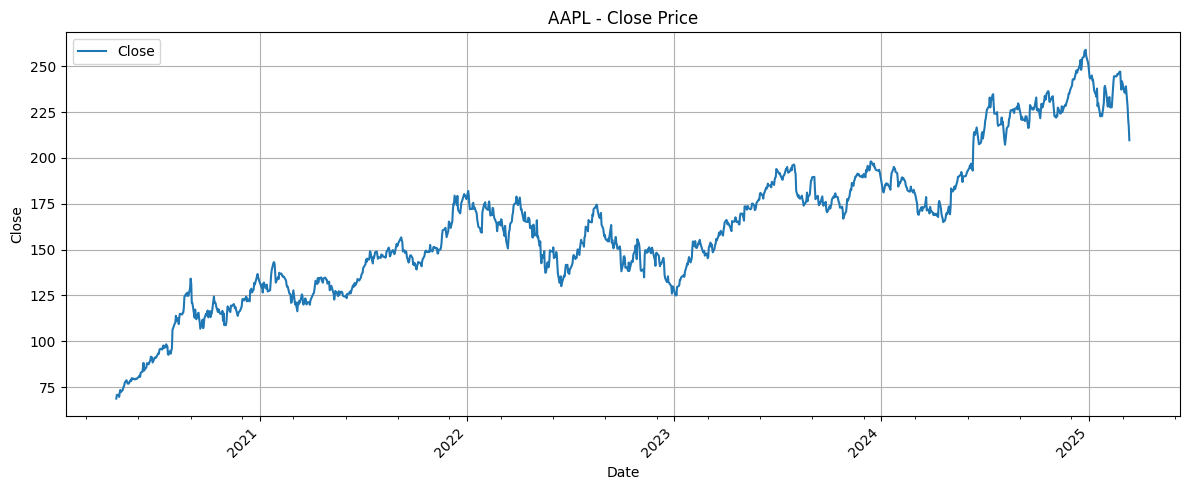

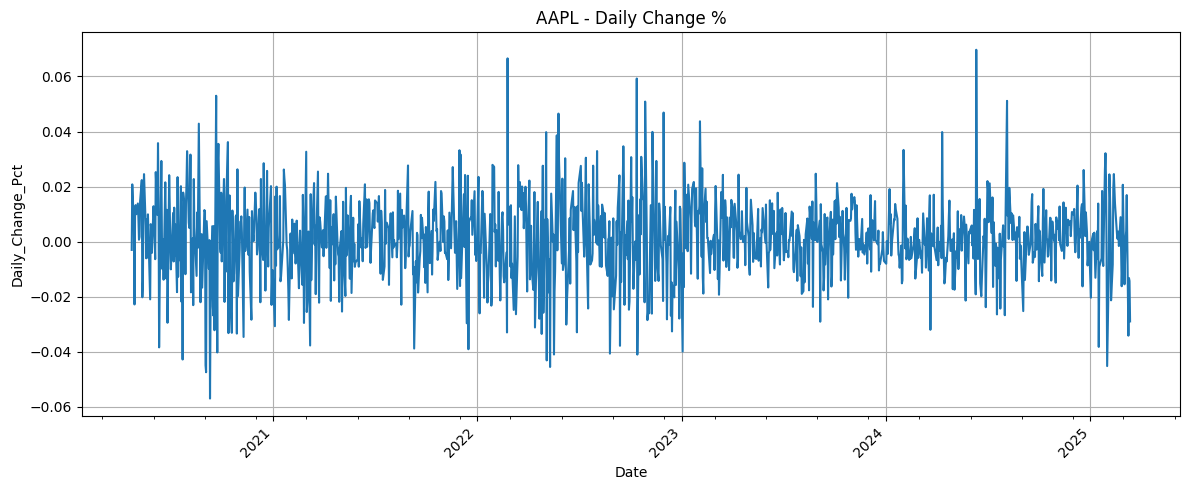

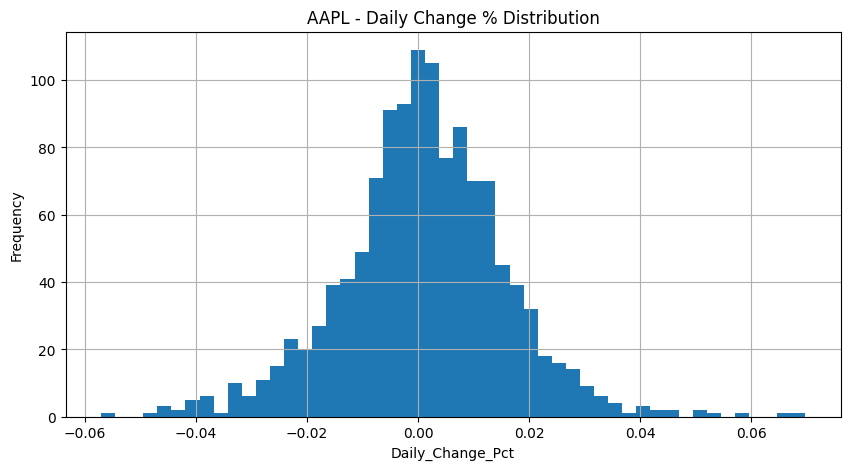

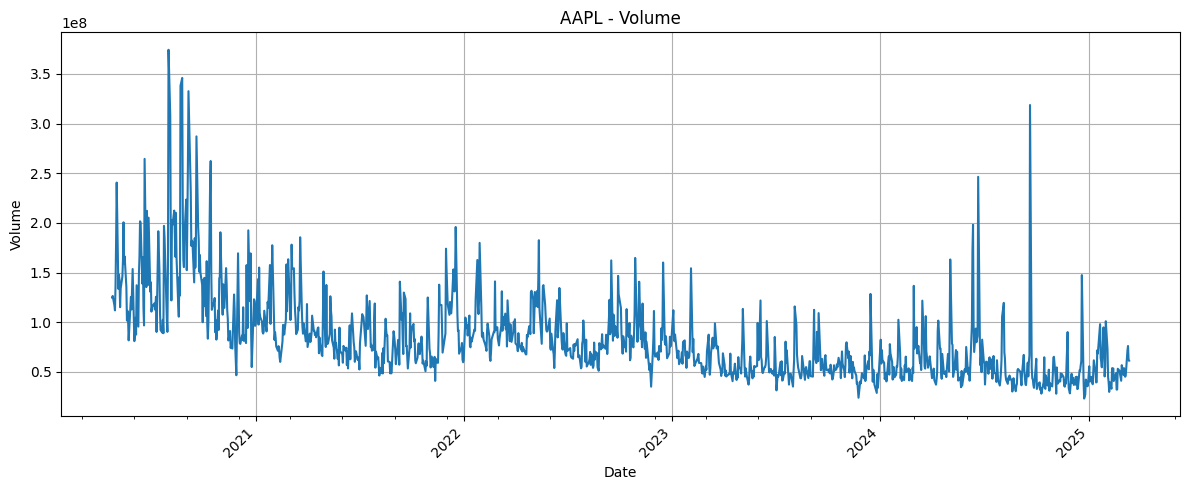

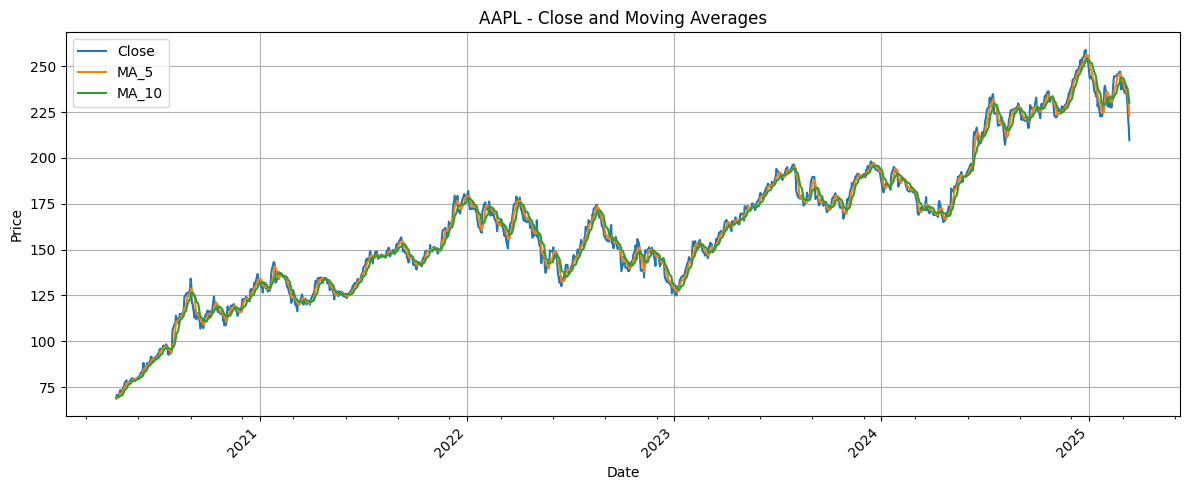

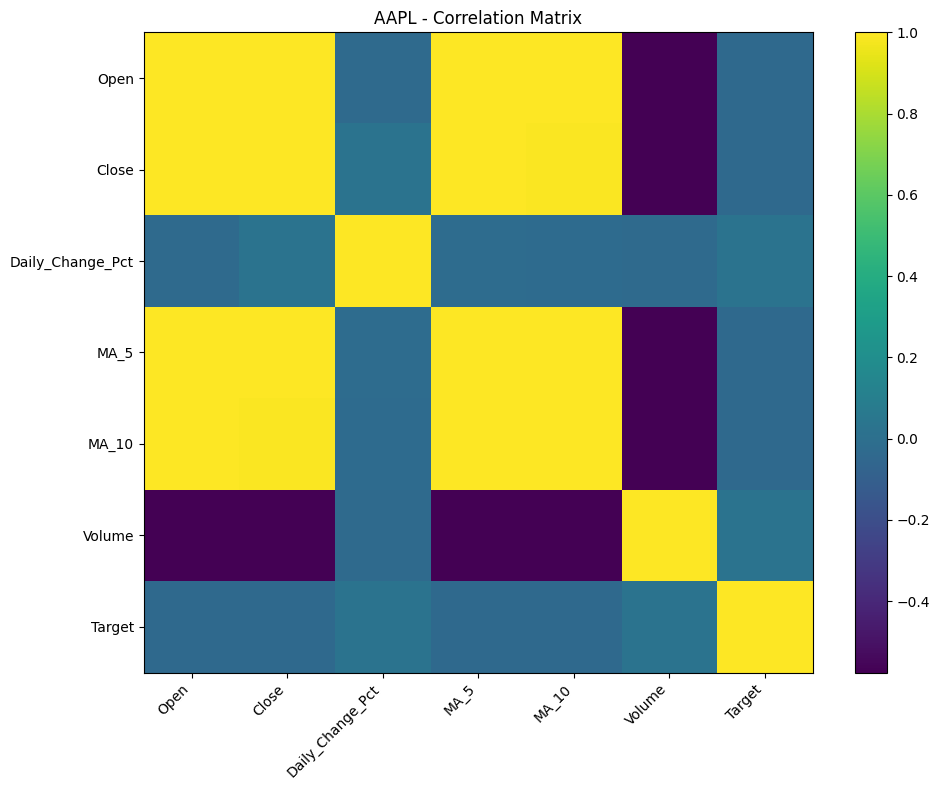

In [26]:
explore_etl_df(df_AAPL, company_name=ticker)

# 7. Train the Baseline Model

We begin with Logistic Regression as the baseline model.

This model is simple, fast, and easy to interpret, which makes it a good starting point for validating the pipeline.

Logistic Regression - Train Accuracy: 0.5463
Logistic Regression - Test Accuracy: 0.4350
Logistic Regression - Precision: 0.5455
Logistic Regression - Recall: 0.0429
Logistic Regression - F1 Score: 0.0795
Logistic Regression - Balanced Accuracy: 0.4978
Logistic Regression - MCC: -0.0103
Logistic Regression - ROC-AUC: 0.5252

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.95      0.59       106
           1       0.55      0.04      0.08       140

    accuracy                           0.43       246
   macro avg       0.49      0.50      0.34       246
weighted avg       0.50      0.43      0.30       246

Logistic Regression - Confusion Matrix:
[[101   5]
 [134   6]]


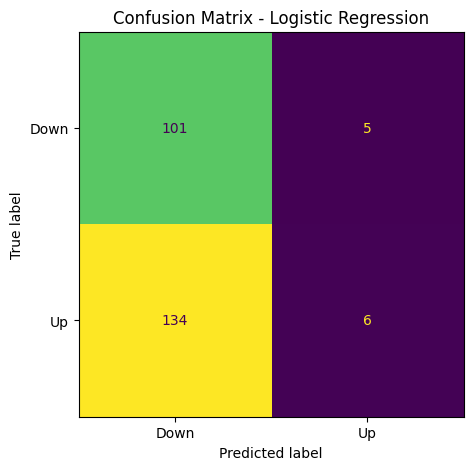

,Actual,Predicted,Prob_Up,Correct,Actual_Label,Predicted_Label
Date,,,,,,
2024-03-20 00:00:00,0,0,0.469,True,Down,Down
2024-03-21 00:00:00,1,0,0.449,False,Up,Down
2024-03-22 00:00:00,0,0,0.497,True,Down,Down
2024-03-25 00:00:00,0,1,0.506,False,Down,Up
2024-03-26 00:00:00,1,1,0.504,True,Up,Up
2024-03-27 00:00:00,0,0,0.497,True,Down,Down
2024-03-28 00:00:00,0,0,0.485,True,Down,Down
2024-04-01 00:00:00,0,0,0.489,True,Down,Down
2024-04-02 00:00:00,1,1,0.503,True,Up,Up


In [27]:
log_output = run_logistic_regression(df_AAPL)

log_output["styled_results"]

# 8. Train the Tree-Based Model

We then train a Gradient Boosted Trees model as a second approach.

This model is useful because it can capture nonlinear relationships that Logistic Regression may miss. In this first comparison, the model is intentionally kept **untuned** and uses its **default parameters** so that it can be compared more evenly against Logistic Regression. This gives a fairer baseline comparison before deciding whether the tree-based model is strong enough to justify further tuning.

## 8.1 Train for Best Params

Gradient Boosted Trees - Train Accuracy: 0.6907
Gradient Boosted Trees - Test Accuracy: 0.4553
Gradient Boosted Trees - Precision: 0.6000
Gradient Boosted Trees - Recall: 0.1286
Gradient Boosted Trees - F1 Score: 0.2118
Gradient Boosted Trees - Balanced Accuracy: 0.5077
Gradient Boosted Trees - MCC: 0.0233
Gradient Boosted Trees - ROC-AUC: 0.5385

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.89      0.58       106
           1       0.60      0.13      0.21       140

    accuracy                           0.46       246
   macro avg       0.52      0.51      0.40       246
weighted avg       0.53      0.46      0.37       246

Gradient Boosted Trees - Confusion Matrix:
[[ 94  12]
 [122  18]]


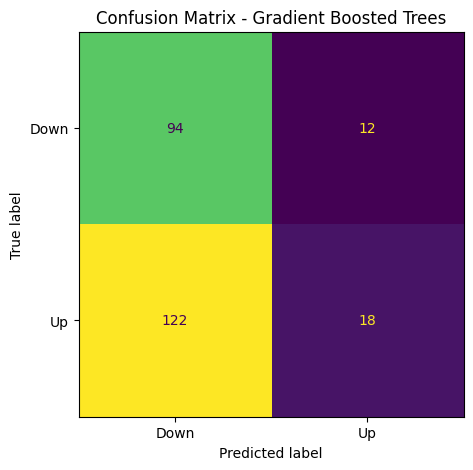

,Actual,Predicted,Prob_Up,Correct,Actual_Label,Predicted_Label
Date,,,,,,
2024-03-20 00:00:00,0,1,0.532,False,Down,Up
2024-03-21 00:00:00,1,0,0.435,False,Up,Down
2024-03-22 00:00:00,0,1,0.545,False,Down,Up
2024-03-25 00:00:00,0,1,0.548,False,Down,Up
2024-03-26 00:00:00,1,1,0.593,True,Up,Up
2024-03-27 00:00:00,0,1,0.563,False,Down,Up
2024-03-28 00:00:00,0,1,0.587,False,Down,Up
2024-04-01 00:00:00,0,1,0.512,False,Down,Up
2024-04-02 00:00:00,1,1,0.541,True,Up,Up


In [28]:
gb_output = run_gradient_boosting(df_AAPL)
gb_output["styled_results"]

# 9. Compare the Models

In this section, we compare the models using:

- train accuracy
- test accuracy
- classification report
- confusion matrix
- visually styled prediction output

The goal is to understand model behavior, not to fully optimize performance.

In [29]:
comparison_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Train Accuracy": log_output["train_accuracy"],
        "Test Accuracy": log_output["test_accuracy"],
        "Overfit Gap": log_output["train_accuracy"] - log_output["test_accuracy"],
        "Precision": log_output["precision"],
        "Recall": log_output["recall"],
        "F1 Score": log_output["f1"],
        "Balanced Accuracy": log_output["balanced_accuracy"],
        "MCC": log_output["mcc"],
        "ROC-AUC": log_output["roc_auc"]
    },
    {
        "Model": "Gradient Boosted Trees",
        "Train Accuracy": gb_output["train_accuracy"],
        "Test Accuracy": gb_output["test_accuracy"],
        "Overfit Gap": gb_output["train_accuracy"] - gb_output["test_accuracy"],
        "Precision": gb_output["precision"],
        "Recall": gb_output["recall"],
        "F1 Score": gb_output["f1"],
        "Balanced Accuracy": gb_output["balanced_accuracy"],
        "MCC": gb_output["mcc"],
        "ROC-AUC": gb_output["roc_auc"]
    }
])


comparison_df

,Model,Train Accuracy,Test Accuracy,Overfit Gap,Precision,Recall,F1 Score,Balanced Accuracy,MCC,ROC-AUC
0,Logistic Regression,0.546287,0.434959,0.111328,0.545455,0.042857,0.079470,0.497844,-0.010333,0.525202
1,Gradient Boosted Trees,0.690743,0.455285,0.235458,0.600000,0.128571,0.211765,0.507682,0.023250,0.538477


## 9.2 Choosing a Model

To make the initial model comparison more balanced, **Logistic Regression** and **Gradient Boosted Trees** were first evaluated using their baseline configurations on the same chronological split. This provided a fairer benchmark for selecting the most promising model family before applying any tuning. In this comparison, **Gradient Boosted Trees** achieved a higher **test accuracy** (**0.4553** vs **0.4350**), a stronger **F1 score** (**0.2118** vs **0.0795**), better **balanced accuracy** (**0.5077** vs **0.4978**), a higher **MCC** (**0.0233** vs **-0.0103**), and a slightly better **ROC-AUC** (**0.5385** vs **0.5252**) than Logistic Regression. Although it showed a larger **overfitting gap** (**0.2355** vs **0.1113**), its stronger overall predictive performance made it the more promising model family, so **Gradient Boosted Trees** was selected for further tuning.

# 10. Generating all Tickers

The pipeline should not be hardcoded for a single ticker.

To confirm that the workflow is reusable, the same ETL and model functions can later be applied to a second company.

## 10.1 Generate Ticker lists and create DFs through etl Pipeline

In [30]:
tickers = ["AAPL", "MSFT", "TSLA", "AMZN", "GOOG", "NVDA", "META", "SPOT"]

datasets = {}

for ticker in tickers:
    company_df = get_company_df(share_prices, ticker)
    datasets[ticker] = build_etl_dataset(company_df, ticker_name=ticker)

AAPL: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
MSFT: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
TSLA: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
AMZN: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
GOOG: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
NVDA: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
META: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)
SPOT: ETL complete: 1238 rows -> 1229 rows (9 dropped due to rolling features and target shift)


## 10.2 Display the new DFs

In [31]:
for ticker in tickers:
    print(f"---------------------------| Company: {ticker} |---------------------------")
    display(datasets[ticker].head(3))
    print()

---------------------------| Company: AAPL |---------------------------


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,68.97,68.76,-0.003045,68.962,69.466,124814328,1
2020-04-24,69.30,70.74,0.020779,68.970,69.840,126508732,1
2020-04-27,70.45,70.79,0.004826,69.282,70.088,117087572,0



---------------------------| Company: MSFT |---------------------------


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,174.11,171.42,-0.015450,173.284,171.969,32790804,1
2020-04-24,172.06,174.55,0.014472,172.474,172.910,34305320,0
2020-04-27,176.59,174.05,-0.014384,172.272,173.764,33194384,0



---------------------------| Company: TSLA |---------------------------


...

,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,7.20,7.10,-0.013889,7.096,7.029,424159520,1
2020-04-24,7.09,7.24,0.021157,7.082,7.096,352645480,1
2020-04-27,7.37,7.43,0.008141,7.132,7.164,479387960,0



---------------------------| Company: META |---------------------------


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,184.08,185.13,0.005704,179.138,177.706,21426604,1
2020-04-24,183.23,190.07,0.037330,181.304,179.194,28868528,0
2020-04-27,192.66,187.50,-0.026783,183.156,180.465,29197750,0



---------------------------| Company: SPOT |---------------------------


,Open,Close,Daily_Change_Pct,MA_5,MA_10,Volume,Target
Date,,,,,,,
2020-04-23,139.75,138.71,-0.007442,140.798,137.988,769452,0
2020-04-24,139.25,137.84,-0.010126,139.994,138.586,1142245,1
2020-04-27,140.10,140.25,0.001071,139.136,139.628,1135455,0


### 10.3 Export Clean Data Frames to CSV

This step exports the cleaned ETL dataset for each ticker into a separate CSV file.

First, a folder named `etl_data` is created if it does not already exist. Then, the notebook loops through all selected tickers and saves each processed dataset into that folder using a consistent filename format such as `AAPL_etl.csv` or `MSFT_etl.csv`.

This makes the ETL output reusable outside the notebook and prepares it for the next step, where a separate script can load these files and train the final models.

In [32]:
etl_dir = Path("etl_data")
etl_dir.mkdir(parents=True, exist_ok=True)

for ticker in tickers:
    output_path = etl_dir / f"{ticker}_etl.csv"
    datasets[ticker].to_csv(output_path, index=True)
    print(f"Saved ETL dataset for {ticker} to {output_path}")

Saved ETL dataset for AAPL to etl_data/AAPL_etl.csv
Saved ETL dataset for MSFT to etl_data/MSFT_etl.csv
Saved ETL dataset for TSLA to etl_data/TSLA_etl.csv
Saved ETL dataset for AMZN to etl_data/AMZN_etl.csv
Saved ETL dataset for GOOG to etl_data/GOOG_etl.csv
Saved ETL dataset for NVDA to etl_data/NVDA_etl.csv
Saved ETL dataset for META to etl_data/META_etl.csv
Saved ETL dataset for SPOT to etl_data/SPOT_etl.csv


## 10.4 Initialize parameter storers
This cell initializes the dictionaries used to store tuning results, final model outputs, and the folder used to export trained models.

In [33]:
all_gb_best_params = {}
all_gb_tuning_results = {}
all_gb_results = {}

model_dir = Path("saved_models")
model_dir.mkdir(parents=True, exist_ok=True)

## 10.5 Tuning Each Ticker Model One at a Time (Takes time)

In this section, each ticker is tuned individually instead of tuning all ticker models at once. This makes the process easier to manage and avoids rerunning a long tuning step every time.

Once the best parameters for a ticker are found, they can be stored and later used to train and export the final model without repeating the tuning process.

In [34]:
ticker = "AAPL"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [35]:
ticker = "MSFT"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [36]:
ticker = "TSLA"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [37]:
ticker = "AMZN"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [38]:
ticker = "GOOG"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [39]:
ticker = "NVDA"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [40]:
ticker = "META"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

In [41]:
ticker = "SPOT"
df_etl = datasets[ticker]

best_params, tuning_results_df = find_best_gb_params(df_etl)

all_gb_best_params[ticker] = best_params
all_gb_tuning_results[ticker] = tuning_results_df

## 10.6 After Tuning, Train and Save Each Ticker Model in a For Loop

After the best parameters have been found for each ticker, the final **Gradient Boosted Trees** models can be trained in a single loop.  
This step uses the stored best parameters for each company, fits the final model, and exports it as a `.joblib` file.

By separating tuning from final training, the workflow becomes more efficient, since the models can be retrained and saved without repeating the expensive tuning step.

---------------------| Company: AAPL |---------------------

Gradient Boosted Trees - Train Accuracy: 0.5565
Gradient Boosted Trees - Test Accuracy: 0.4797
Gradient Boosted Trees - Precision: 0.6304
Gradient Boosted Trees - Recall: 0.2071
Gradient Boosted Trees - F1 Score: 0.3118
Gradient Boosted Trees - Balanced Accuracy: 0.5234
Gradient Boosted Trees - MCC: 0.0594
Gradient Boosted Trees - ROC-AUC: 0.5365

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.84      0.58       106
           1       0.63      0.21      0.31       140

    accuracy                           0.48       246
   macro avg       0.54      0.52      0.45       246
weighted avg       0.55      0.48      0.43       246

Gradient Boosted Trees - Confusion Matrix:
[[ 89  17]
 [111  29]]


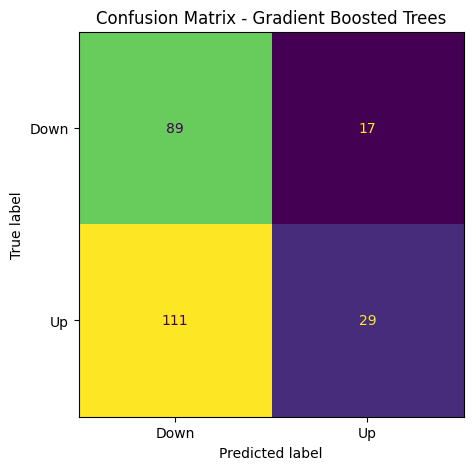

Saved model to: saved_models/gradient_boosting_AAPL.joblib


---------------------| Company: MSFT |---------------------

Gradient Boosted Trees - Train Accuracy: 0.6378
Gradient Boosted Trees - Test Accuracy: 0.5325
Gradient Boosted Trees - Precision: 0.6415
Gradient Boosted Trees - Recall: 0.2615
Gradient Boosted Trees - F1 Score: 0.3716
Gradient Boosted Trees - Balanced Accuracy: 0.5489
Gradient Boosted Trees - MCC: 0.1187
Gradient Boosted Trees - ROC-AUC: 0.5004

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.84      0.63       116
           1       0.64      0.26      0.37       130

    accuracy                           0.53       246
   macro avg       0.57      0.55      0.50       246
weighted avg       0.58      0.53      0.49       246

Gradient Boosted Trees - Confusion Matrix:
[[97 19]
 [96 34]]


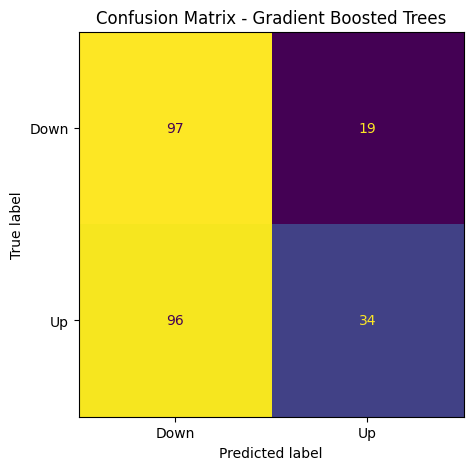

Saved model to: saved_models/gradient_boosting_MSFT.joblib


---------------------| Company: TSLA |---------------------

Gradient Boosted Trees - Train Accuracy: 0.5931
Gradient Boosted Trees - Test Accuracy: 0.5569
Gradient Boosted Trees - Precision: 0.5391
Gradient Boosted Trees - Recall: 0.5798
Gradient Boosted Trees - F1 Score: 0.5587
Gradient Boosted Trees - Balanced Accuracy: 0.5576
Gradient Boosted Trees - MCC: 0.1153
Gradient Boosted Trees - ROC-AUC: 0.5631

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.54      0.56       127
           1       0.54      0.58      0.56       119

    accuracy                           0.56       246
   macro avg       0.56      0.56      0.56       246
weighted avg       0.56      0.56      0.56       246

Gradient Boosted Trees - Confusion Matrix:
[[68 59]
 [50 69]]


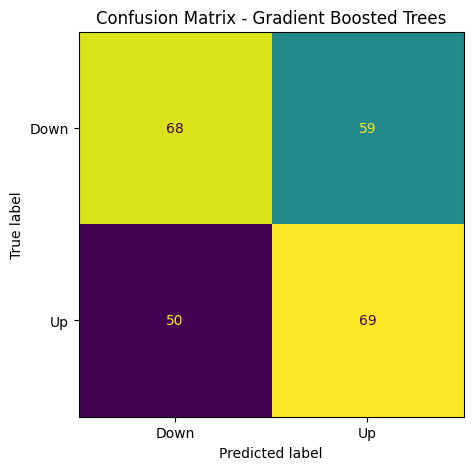

Saved model to: saved_models/gradient_boosting_TSLA.joblib


---------------------| Company: AMZN |---------------------

Gradient Boosted Trees - Train Accuracy: 0.6694
Gradient Boosted Trees - Test Accuracy: 0.5528
Gradient Boosted Trees - Precision: 0.6111
Gradient Boosted Trees - Recall: 0.3492
Gradient Boosted Trees - F1 Score: 0.4444
Gradient Boosted Trees - Balanced Accuracy: 0.5579
Gradient Boosted Trees - MCC: 0.1273
Gradient Boosted Trees - ROC-AUC: 0.5494

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.77      0.63       120
           1       0.61      0.35      0.44       126

    accuracy                           0.55       246
   macro avg       0.57      0.56      0.54       246
weighted avg       0.57      0.55      0.53       246

Gradient Boosted Trees - Confusion Matrix:
[[92 28]
 [82 44]]


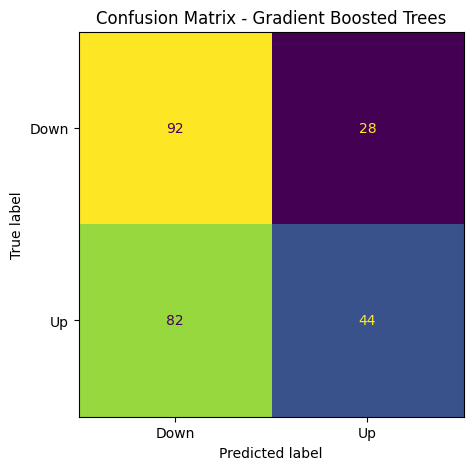

Saved model to: saved_models/gradient_boosting_AMZN.joblib


---------------------| Company: GOOG |---------------------

Gradient Boosted Trees - Train Accuracy: 0.5453
Gradient Boosted Trees - Test Accuracy: 0.5569
Gradient Boosted Trees - Precision: 0.6053
Gradient Boosted Trees - Recall: 0.6525
Gradient Boosted Trees - F1 Score: 0.6280
Gradient Boosted Trees - Balanced Accuracy: 0.5405
Gradient Boosted Trees - MCC: 0.0825
Gradient Boosted Trees - ROC-AUC: 0.5382

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.43      0.45       105
           1       0.61      0.65      0.63       141

    accuracy                           0.56       246
   macro avg       0.54      0.54      0.54       246
weighted avg       0.55      0.56      0.55       246

Gradient Boosted Trees - Confusion Matrix:
[[45 60]
 [49 92]]


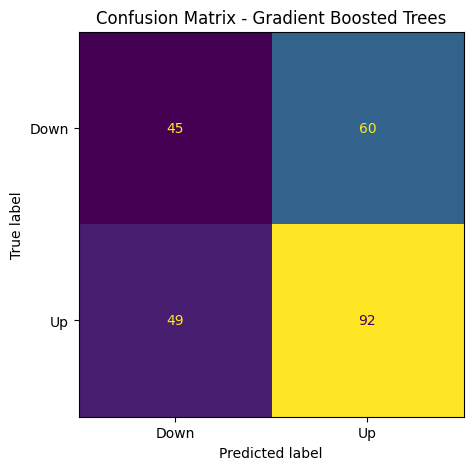

Saved model to: saved_models/gradient_boosting_GOOG.joblib


---------------------| Company: NVDA |---------------------

Gradient Boosted Trees - Train Accuracy: 0.7172
Gradient Boosted Trees - Test Accuracy: 0.5081
Gradient Boosted Trees - Precision: 0.6154
Gradient Boosted Trees - Recall: 0.1846
Gradient Boosted Trees - F1 Score: 0.2840
Gradient Boosted Trees - Balanced Accuracy: 0.5277
Gradient Boosted Trees - MCC: 0.0756
Gradient Boosted Trees - ROC-AUC: 0.4870

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.87      0.63       116
           1       0.62      0.18      0.28       130

    accuracy                           0.51       246
   macro avg       0.55      0.53      0.45       246
weighted avg       0.56      0.51      0.44       246

Gradient Boosted Trees - Confusion Matrix:
[[101  15]
 [106  24]]


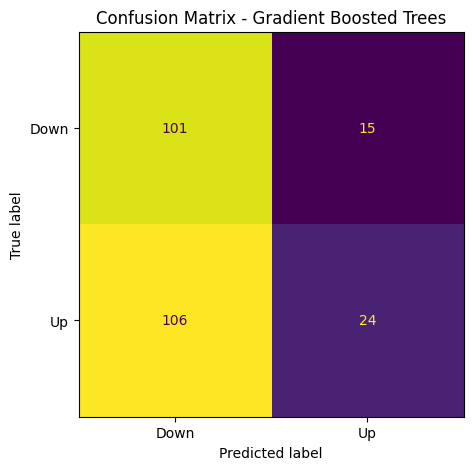

Saved model to: saved_models/gradient_boosting_NVDA.joblib


---------------------| Company: META |---------------------

Gradient Boosted Trees - Train Accuracy: 0.7213
Gradient Boosted Trees - Test Accuracy: 0.5203
Gradient Boosted Trees - Precision: 0.7667
Gradient Boosted Trees - Recall: 0.1716
Gradient Boosted Trees - F1 Score: 0.2805
Gradient Boosted Trees - Balanced Accuracy: 0.5546
Gradient Boosted Trees - MCC: 0.1661
Gradient Boosted Trees - ROC-AUC: 0.5578

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.94      0.64       112
           1       0.77      0.17      0.28       134

    accuracy                           0.52       246
   macro avg       0.63      0.55      0.46       246
weighted avg       0.64      0.52      0.44       246

Gradient Boosted Trees - Confusion Matrix:
[[105   7]
 [111  23]]


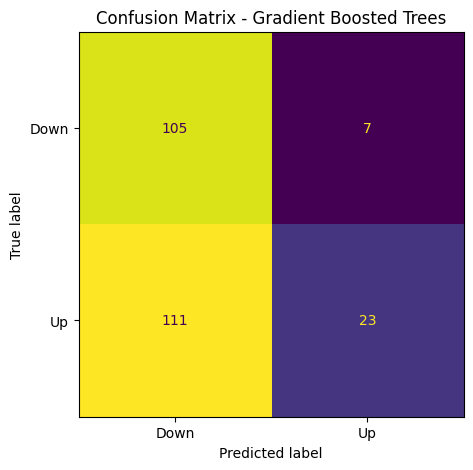

Saved model to: saved_models/gradient_boosting_META.joblib


---------------------| Company: SPOT |---------------------

Gradient Boosted Trees - Train Accuracy: 0.5717
Gradient Boosted Trees - Test Accuracy: 0.4593
Gradient Boosted Trees - Precision: 0.7143
Gradient Boosted Trees - Recall: 0.0368
Gradient Boosted Trees - F1 Score: 0.0699
Gradient Boosted Trees - Balanced Accuracy: 0.5093
Gradient Boosted Trees - MCC: 0.0556
Gradient Boosted Trees - ROC-AUC: 0.4684

Gradient Boosted Trees - Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.98      0.62       110
           1       0.71      0.04      0.07       136

    accuracy                           0.46       246
   macro avg       0.58      0.51      0.34       246
weighted avg       0.60      0.46      0.32       246

Gradient Boosted Trees - Confusion Matrix:
[[108   2]
 [131   5]]


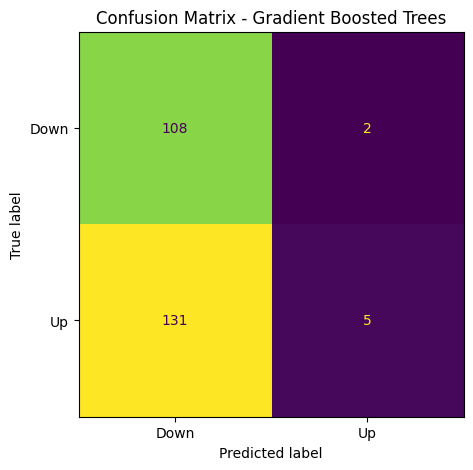

Saved model to: saved_models/gradient_boosting_SPOT.joblib




In [42]:
model_dir = Path("saved_models")
model_dir.mkdir(parents=True, exist_ok=True)

for ticker in tickers:
    print(f"---------------------| Company: {ticker} |---------------------\n")
    df_etl = datasets[ticker]
    best_params = all_gb_best_params[ticker]

    gb_output = run_gradient_boosting(df_etl, params=best_params)
    all_gb_results[ticker] = gb_output

    model_path = model_dir / f"gradient_boosting_{ticker}.joblib"
    joblib.dump(gb_output["model"], model_path)

    print(f"Saved model to: {model_path}\n\n")

## 10.7 Summary Table for the model
This step creates a summary table for all tickers after training the tuned **Gradient Boosted Trees** models.

For each ticker, the table includes:

- the main performance metrics:
  - Train Accuracy
  - Test Accuracy
  - Overfit Gap
  - F1 Score
  - Balanced Accuracy
  - ROC-AUC
- the best hyperparameters selected during tuning

The result is stored in `gb_summary_df`, which provides a consolidated view of model performance and parameter choices across all companies.

In [43]:
gb_summary_rows = []

for ticker in tickers:
    result = all_gb_results[ticker]
    params = all_gb_best_params[ticker]

    gb_summary_rows.append({
        "Ticker": ticker,
        "Train Accuracy": result["train_accuracy"],
        "Test Accuracy": result["test_accuracy"],
        "Overfit Gap": result["train_accuracy"] - result["test_accuracy"],
        "Precision": result["precision"],
        "Recall": result["recall"],
        "F1 Score": result["f1"],
        "Balanced Accuracy": result["balanced_accuracy"],
        "MCC": result["mcc"],
        "ROC-AUC": result["roc_auc"],
        **params
    })

gb_summary_df = pd.DataFrame(gb_summary_rows)
gb_summary_df

,Ticker,Train Accuracy,Test Accuracy,Overfit Gap,Precision,Recall,F1 Score,Balanced Accuracy,MCC,ROC-AUC,n_estimators,learning_rate,max_depth,subsample,min_samples_split,min_samples_leaf
0,AAPL,0.556460,0.479675,0.076785,0.630435,0.207143,0.311828,0.523383,0.059395,0.536523,50,0.01,2,0.6,10,5
1,MSFT,0.637843,0.532520,0.105323,0.641509,0.261538,0.371585,0.548873,0.118681,0.500398,200,0.01,2,0.8,20,5
2,TSLA,0.593082,0.556911,0.036172,0.539062,0.579832,0.558704,0.557633,0.115299,0.563124,200,0.02,1,0.6,10,10
3,AMZN,0.669379,0.552846,0.116534,0.611111,0.349206,0.444444,0.557937,0.127297,0.549405,200,0.02,2,0.6,10,5
4,GOOG,0.545270,0.556911,-0.011641,0.605263,0.652482,0.627986,0.540527,0.082507,0.538197,50,0.01,2,0.7,20,5
5,NVDA,0.717192,0.508130,0.209062,0.615385,0.184615,0.284024,0.527653,0.075587,0.487036,200,0.05,2,0.8,10,5
6,META,0.721261,0.520325,0.200936,0.766667,0.171642,0.280488,0.554571,0.166098,0.557836,200,0.05,2,0.6,20,5
7,SPOT,0.571719,0.459350,0.112370,0.714286,0.036765,0.069930,0.509291,0.055569,0.468382,50,0.05,1,0.6,10,5


# 11. Conclusion

This notebook was used to build and validate the core data and modeling pipeline for the project. It first helped us understand the structure and quality of the historical stock market data, explore one company in detail, and confirm that the selected variables could be transformed into a clean and reusable ETL dataset. From there, the notebook was used to compare candidate machine learning models, evaluate their behavior on time-ordered stock data, and select the final modeling approach for the selected tickers.

In addition to supporting analysis and experimentation, this notebook also served as the foundation for the reusable project scripts. The ETL logic developed here was transferred into a standalone script that can load or generate the raw CSV files and export cleaned datasets, while the model-training logic was adapted into a separate script that reads the ETL outputs, trains the selected models, and saves them for later use in the web application. In this way, the notebook was not only an exploration tool, but also the basis for the automated pipeline used in the final project workflow.